**TARGET**
* Go to a **very small model** *less than 5k parameters*
* Benchmark what can we achieve within 15 epochs.

**RESULT**
1. Parameters: **3,272**
2. Best Train Accuracy: **98.39**
3. Best Test Accuracy: **98.83**

**ANALYSIS**
1. The model works well with batch size of 64 without changing LR (0.01).
2. The parameters are quite less and the model could not breach 99% in 15 epochs.
3. Probably the output channels are much less that what is required, somewhere around 10k is probably a sweet spot in terms of number of parameters.
4. We need to increase output channel size and also add some image augmentation in next run.
5. The model is underfitting, so not need to add dropout at this stage.





# Import Libraries

In [3]:
from __future__ import print_function
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms

## Data Transformations

We first start with defining our data transformations. We need to think what our data is and how can we augment it to correct represent images which it might not see otherwise.


In [ ]:
# Train Phase transformations
train_transforms = transforms.Compose([
                                      #  transforms.Resize((28, 28)),
                                      #  transforms.ColorJitter(brightness=0.10, contrast=0.1, saturation=0.10, hue=0.1),
                                       transforms.RandomRotation((-7.0, 7.0), fill=(1,)),
                                       transforms.ToTensor(),
                                       transforms.Normalize((0.1307,), (0.3081,)) # The mean and std have to be sequences (e.g., tuples), therefore you should add a comma after the values.
                                       # Note the difference between (0.1307) and (0.1307,)
                                       ])

# Test Phase transformations
test_transforms = transforms.Compose([
                                      #  transforms.Resize((28, 28)),
                                      #  transforms.ColorJitter(brightness=0.10, contrast=0.1, saturation=0.10, hue=0.1),
                                       transforms.ToTensor(),
                                       transforms.Normalize((0.1307,), (0.3081,))
                                       ])


# Dataset and Creating Train/Test Split

In [ ]:
train = datasets.MNIST('./data', train=True, download=True, transform=train_transforms)
test = datasets.MNIST('./data', train=False, download=True, transform=test_transforms)

100%|██████████| 9.91M/9.91M [00:01<00:00, 4.99MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 131kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.23MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.56MB/s]


# Dataloader Arguments & Test/Train Dataloaders


In [ ]:
SEED = 1

# CUDA?
cuda = torch.cuda.is_available()
print("CUDA Available?", cuda)

# For reproducibility
torch.manual_seed(SEED)

if cuda:
    torch.cuda.manual_seed(SEED)

# dataloader arguments - something you'll fetch these from cmdprmt
dataloader_args = dict(shuffle=True, batch_size=64, num_workers=4, pin_memory=True) if cuda else dict(shuffle=True, batch_size=64)

# train dataloader
train_loader = torch.utils.data.DataLoader(train, **dataloader_args)

# test dataloader
test_loader = torch.utils.data.DataLoader(test, **dataloader_args)

CUDA Available? True


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:627: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


# Data Statistics

It is important to know your data very well. Let's check some of the statistics around our data and how it actually looks like

[Train]
 - Shape: torch.Size([60000, 28, 28])
 - Type: torch.uint8
 - min: tensor(0, dtype=torch.uint8)
 - max: tensor(255, dtype=torch.uint8)
 - mean: tensor(33.3184)
 - std: tensor(78.5675)
 - var: tensor(6172.8506)
torch.Size([64, 1, 28, 28])
torch.Size([64])


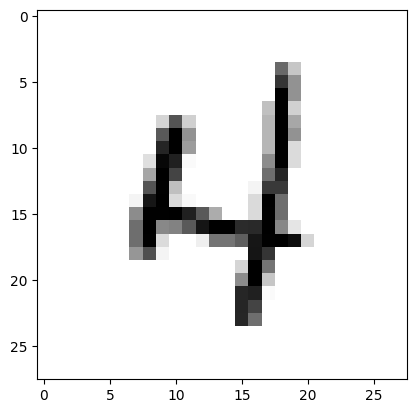

In [ ]:
# Calculate statistics on the raw training data
train_data = train.data

print('[Train]')
print(' - Shape:', train_data.shape)
print(' - Type:', train_data.dtype)
print(' - min:', torch.min(train_data))
print(' - max:', torch.max(train_data))
print(' - mean:', torch.mean(train_data.float())) # Convert to float for mean calculation
print(' - std:', torch.std(train_data.float()))   # Convert to float for std calculation
print(' - var:', torch.var(train_data.float()))   # Convert to float for var calculation


dataiter = iter(train_loader)
images, labels = next(dataiter)

print(images.shape)
print(labels.shape)

# Let's visualize some of the images
%matplotlib inline
import matplotlib.pyplot as plt

plt.imshow(images[0].numpy().squeeze(), cmap='gray_r')

## MORE

It is important that we view as many images as possible. This is required to get some idea on image augmentation later on

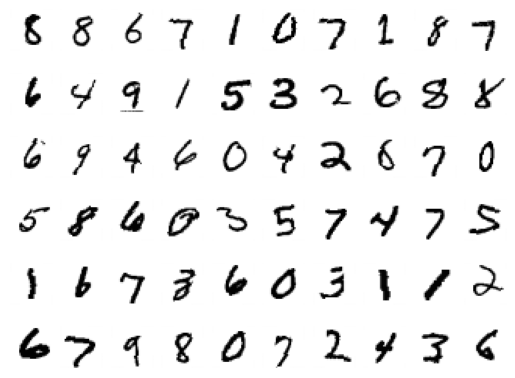

In [ ]:
figure = plt.figure()
num_of_images = 60
for index in range(1, num_of_images + 1):
    plt.subplot(6, 10, index)
    plt.axis('off')
    plt.imshow(images[index].numpy().squeeze(), cmap='gray_r')

# The model
Let's start with the model we first saw

In [1]:
from model_2 import Net

# Model Params
Can't emphasize on how important viewing Model Summary is.
Unfortunately, there is no in-built model visualizer, so we have to take external help

In [4]:
# !pip install torchsummary
from torchsummary import summary
use_cuda = torch.cuda.is_available()
device = torch.device("cuda" if use_cuda else "cpu")
print(device)
model = Net().to(device)
summary(model, input_size=(1, 28, 28))

cuda
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1            [-1, 4, 26, 26]              36
              ReLU-2            [-1, 4, 26, 26]               0
       BatchNorm2d-3            [-1, 4, 26, 26]               8
           Dropout-4            [-1, 4, 26, 26]               0
            Conv2d-5            [-1, 8, 24, 24]             288
              ReLU-6            [-1, 8, 24, 24]               0
       BatchNorm2d-7            [-1, 8, 24, 24]              16
           Dropout-8            [-1, 8, 24, 24]               0
            Conv2d-9           [-1, 16, 22, 22]           1,152
             ReLU-10           [-1, 16, 22, 22]               0
      BatchNorm2d-11           [-1, 16, 22, 22]              32
          Dropout-12           [-1, 16, 22, 22]               0
        MaxPool2d-13           [-1, 16, 11, 11]               0
           Conv2d-14            [-

# Training and Testing

Looking at logs can be boring, so we'll introduce **tqdm** progressbar to get cooler logs.

Let's write train and test functions

In [ ]:
from tqdm import tqdm

train_losses = []
test_losses = []
train_acc = []
test_acc = []

def train(model, device, train_loader, optimizer, epoch):
  model.train()
  pbar = tqdm(train_loader)
  correct = 0
  processed = 0
  for batch_idx, (data, target) in enumerate(pbar):
    # get samples
    data, target = data.to(device), target.to(device)

    # Init
    optimizer.zero_grad()
    # In PyTorch, we need to set the gradients to zero before starting to do backpropragation because PyTorch accumulates the gradients on subsequent backward passes.
    # Because of this, when you start your training loop, ideally you should zero out the gradients so that you do the parameter update correctly.

    # Predict
    y_pred = model(data)

    # Calculate loss
    loss = F.nll_loss(y_pred, target)
    train_losses.append(loss)

    # Backpropagation
    loss.backward()
    optimizer.step()

    # Update pbar-tqdm

    pred = y_pred.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
    correct += pred.eq(target.view_as(pred)).sum().item()
    processed += len(data)

    pbar.set_description(desc= f'Loss={loss.item()} Batch_id={batch_idx} Accuracy={100*correct/processed:0.2f}')
    train_acc.append(100*correct/processed)

def test(model, device, test_loader):
    model.eval()
    test_loss = 0
    correct = 0
    with torch.no_grad():
        for data, target in test_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            test_loss += F.nll_loss(output, target, reduction='sum').item()  # sum up batch loss
            pred = output.argmax(dim=1, keepdim=True)  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    test_losses.append(test_loss)

    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset),
        100. * correct / len(test_loader.dataset)))

    test_acc.append(100. * correct / len(test_loader.dataset))

# Let's Train and test our model

In [ ]:
model =  Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
EPOCHS = 16
for epoch in range(EPOCHS):
    print("EPOCH:", epoch)
    train(model, device, train_loader, optimizer, epoch)
    test(model, device, test_loader)

EPOCH: 0


Loss=0.19020628929138184 Batch_id=937 Accuracy=88.64: 100%|██████████| 938/938 [00:23<00:00, 40.68it/s]



Test set: Average loss: 0.1590, Accuracy: 9685/10000 (96.85%)

EPOCH: 1


Loss=0.1537032425403595 Batch_id=937 Accuracy=96.07: 100%|██████████| 938/938 [00:23<00:00, 40.47it/s]



Test set: Average loss: 0.1088, Accuracy: 9772/10000 (97.72%)

EPOCH: 2


...


Test set: Average loss: 0.0412, Accuracy: 9877/10000 (98.77%)

EPOCH: 14


Loss=0.027950117364525795 Batch_id=937 Accuracy=98.29: 100%|██████████| 938/938 [00:22<00:00, 42.32it/s]



Test set: Average loss: 0.0390, Accuracy: 9886/10000 (98.86%)

EPOCH: 15


Loss=0.029718825593590736 Batch_id=937 Accuracy=98.39: 100%|██████████| 938/938 [00:21<00:00, 43.08it/s]



Test set: Average loss: 0.0437, Accuracy: 9883/10000 (98.83%)



In [ ]:
model =  Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
EPOCHS = 16
for epoch in range(EPOCHS):
    print("EPOCH:", epoch)
    train(model, device, train_loader, optimizer, epoch)
    test(model, device, test_loader)

EPOCH: 0


Loss=0.2876218557357788 Batch_id=468 Accuracy=85.74: 100%|██████████| 469/469 [00:18<00:00, 25.57it/s]



Test set: Average loss: 0.2168, Accuracy: 9638/10000 (96.38%)

EPOCH: 1


Loss=0.15709789097309113 Batch_id=468 Accuracy=95.53: 100%|██████████| 469/469 [00:17<00:00, 26.29it/s]



Test set: Average loss: 0.1666, Accuracy: 9685/10000 (96.85%)

EPOCH: 2


...


Test set: Average loss: 0.0567, Accuracy: 9841/10000 (98.41%)

EPOCH: 14


Loss=0.03904366120696068 Batch_id=468 Accuracy=98.11: 100%|██████████| 469/469 [00:19<00:00, 23.80it/s]



Test set: Average loss: 0.0621, Accuracy: 9819/10000 (98.19%)

EPOCH: 15


Loss=0.13858537375926971 Batch_id=468 Accuracy=98.13: 100%|██████████| 469/469 [00:18<00:00, 25.84it/s]



Test set: Average loss: 0.0688, Accuracy: 9809/10000 (98.09%)



In [ ]:
model =  Net().to(device)
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
EPOCHS = 16
for epoch in range(EPOCHS):
    print("EPOCH:", epoch)
    train(model, device, train_loader, optimizer, epoch)
    test(model, device, test_loader)

EPOCH: 0


Loss=0.853141725063324 Batch_id=117 Accuracy=68.30: 100%|██████████| 118/118 [00:15<00:00,  7.77it/s]



Test set: Average loss: 0.7614, Accuracy: 8930/10000 (89.30%)

EPOCH: 1


Loss=0.3964713513851166 Batch_id=117 Accuracy=91.56: 100%|██████████| 118/118 [00:15<00:00,  7.66it/s]



Test set: Average loss: 0.3733, Accuracy: 9462/10000 (94.62%)

EPOCH: 2


...


Test set: Average loss: 0.0890, Accuracy: 9792/10000 (97.92%)

EPOCH: 14


Loss=0.09774952381849289 Batch_id=117 Accuracy=97.78: 100%|██████████| 118/118 [00:15<00:00,  7.85it/s]



Test set: Average loss: 0.0893, Accuracy: 9778/10000 (97.78%)

EPOCH: 15


Loss=0.09973769634962082 Batch_id=117 Accuracy=97.87: 100%|██████████| 118/118 [00:14<00:00,  7.87it/s]



Test set: Average loss: 0.0943, Accuracy: 9788/10000 (97.88%)



Text(0.5, 1.0, 'Test Accuracy')

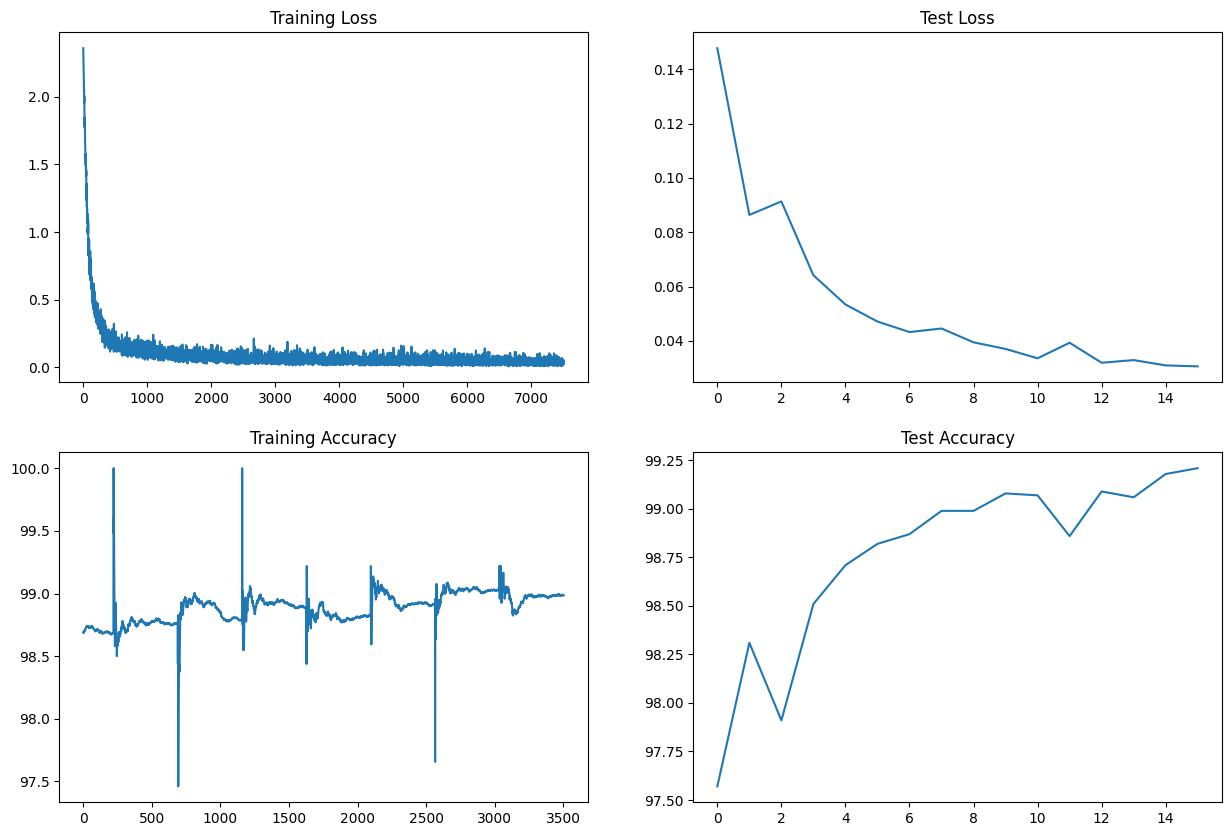

In [ ]:
t = [t_items.item() for t_items in train_losses]
%matplotlib inline
import matplotlib.pyplot as plt
fig, axs = plt.subplots(2,2,figsize=(15,10))
axs[0, 0].plot(t)
axs[0, 0].set_title("Training Loss")
axs[1, 0].plot(train_acc[4000:])
axs[1, 0].set_title("Training Accuracy")
axs[0, 1].plot(test_losses)
axs[0, 1].set_title("Test Loss")
axs[1, 1].plot(test_acc)
axs[1, 1].set_title("Test Accuracy")